<a href="https://colab.research.google.com/github/Saugat-Chaudhary/nn-zero-to-hero/blob/master/my_activities/MLP/makemore_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Building Multi-layer perceptron

![Picture of inspired architecture for MLP](./mlp_arch.png)

_Note: Our MLP model is inspired by same architecture where we have implemented embedding matrix for lookup, then used two hidden layer._

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

__Difference between adding `.splitlines()` while reading and not adding `.splitlines()`?__

Answer: When we don't add `splitlines()` then python reads by default one character at a time because that's how reading and writing in done in all programming language.

But when we add the `.splitlines()` then we instruct the python to read one whole line at a time.

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

We are still reading the same file `name.txt` from our previous lecture about the `bigram` model. We will read the file line by line instead of default character by character. Then we will construct to dictionary same as previous lecture:
1. dictionary to translate the string into integer
2. dictionary to translate integer into string

`sorted(list(set(('').join(words))))`: returns sorted list of alphabets from 'a' to 'z' in a list because `.set()` only keeps unique character and doesn't store already stored character.

In [4]:
chars = sorted(list(set(('').join(words))))
# our target is to form two dictionary `stoi` and `itos` for character mapping
stoi = {s:i+1 for i, s in enumerate(chars)}
# store '.' as the first string
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()} # because a dictionary returns 'key' then 'value'
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


We are building a multi-layer perceptron to predict more realistic name so, we have decided to predict fourth character after taking three previous character as input. Therefore, we set `block_size = 3`.

Here, `X` represents the dataset with integer embedding for three previous character. `Y` represents the dataset with integer embedding for the fourth character which we want to predict.

But first we will build the MLP model using the first 5 words only.
- `context = [0] * block_size`, we are creating a list of integer containing `[0, 0, 0]` which translates to `[., ., .]` .
- `for ch in w + '.'`, we are looping through a word like `emma.` because we are adding `'.'` at the end of each word.
- `idx = stoi[ch]`, we are getting index of each character like `e`.
- `X.append(context)`,  we are storing `[0 ,0 ,0 ]` which translates to `[. ,. ,. ]` into our `X` dataset followed by `[0 ,0 ,5 ]` which translates to `[. ,. , e]` and so on.
- `Y.append(idx)`, we are storing `[5]` which translates to `[e]` into our `Y` dataset because `... ---> e`, `e` is our targetted word which we want to predict after `...` as starting first character. Similarly if our `X` is `[. ,. ,e ]` then `Y` should have targetted word would be `[14]` representing `m`. Therefore, we are storing `[5, 14, .......]` in `Y`.
- `print(''.join(itos[i] for i in context), '--->', itos[idx])`, we are trying to visualize each of our context which are stored in `X` then corresponding character stored in `Y`. For example: <br>... ---> e<br>..e ---> m<br>.em ---> m<br>emm ---> a<br>mma ---> .<br>
- `context = context[1:] + [idx]`, we are creating for next loop by making new context using slice method to element the very first character and then keeping second and third previous character withh new one. For example, previous `context [0 ,0 ,0 ]` then making new `context [0 ,0 ,5 ]`.

__Confusing question:__
1. Difference between [:1] and [1:]?

Answer: To understand this, we need to understand this `[start : end]`. In a slicing method of a list, it expects a starting point then : stoping point. Starting point is inclusive and end point is exclusive.
- if we pass [1:] : this means start from index `1` and since, end point is missing so go and include everything till list ends itself. So, index 1 element is included in new sliced list.
- if we pass [:1]: this means start from first element because we are missing the start point then stop at index `1`. Since, index `1` is stopping point so element at index `1` is not including in new sliced list. Therefore, resulting list will only include the `[0]`.

In [5]:
block_size = 3
X, Y = [], []

for w in words[:5]:
  # print (w)
  context = [0] * block_size
  # print (context)
  for ch in w + '.':
    # print(ch)
    idx = stoi[ch]
    X.append(context)
    Y.append(idx)
    print(''.join(itos[i] for i in context), '--->', itos[idx])
    context = context[1:] + [idx]

... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
... ---> a
..a ---> v
.av ---> a
ava ---> .
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


Let's convert our datasets into `tensor`and look into our datasets `X` and `Y`.

In [6]:
X = torch.tensor(X)
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [7]:
Y = torch.tensor(Y)

In [8]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

We are trying to create the matrix `C` for our 27 characters with 2 randomly assigned weight so that our model can learn during the backpropagation.

In [9]:
C = torch.randn((27,2))

Since our current dataset X has size of `32 X 3` where we have 32 rows with 3 columns. Each rows contain 3 context which are integer representing the a character among 27. Our target here is to embed these two feature into each element of the `X` matrix.

As usual, we can do this by doing `one-hot encodding` which would make our X `32 X 3 X 27` so that it can match, `27 X 2` which would have resulted matrix into `32 X 3 X 2`.

Why is this possible?

Answer: For matrix multiplication, the rule is always that the inner dimensions must match (the columns of the first must equal the rows of the second).

- Look at the very last dimension of X (27) and the first dimension of C (27).

- They match. This satisfies the core rule of matrix multiplication.

In [10]:
# import torch.nn.functional as F
# X = F.one_hot(X, num_classes= 27).float()
# emb = X @ C
# X.shape

But we will do it in much more efficient way because multiplying the one-hot encoded matrix C will cause huge compuation loss. We can achieve same target by using `C[]` indexing method. We can see below that, when we use indexing, it plugs out exactly that particular element from the C matrix.

In [11]:
C[[0,1,2,3,0,1]]

tensor([[-2.7686e-01, -1.7997e+00],
        [-8.7629e-01, -4.3077e-01],
        [-1.2100e+00,  1.4341e+00],
        [-3.9107e-01, -3.7026e-04],
        [-2.7686e-01, -1.7997e+00],
        [-8.7629e-01, -4.3077e-01]])

let's verify it. We can see that, in our `X` matrix at 13th row and 2nd column, we have 1. And if we do C[X], it will embed the C[1] in that new resulting embedded matrix.

In [12]:
X[13,2]

tensor(1)

In [13]:
C[X][13,2]

tensor([-0.8763, -0.4308])

In [14]:
C[1]

tensor([-0.8763, -0.4308])

When we pass `X` into the `C` matrix as `C[X]`, we are saying look into those particular element id and pluck out those element. We are using the indexing method because it achieves the same goal as one-hot encoding with less computation. One-hot encoding is inefficent because each row with 27 long column with 26 zero and only one integer will pluck out 1 elment same as indexing.

### Tracking Dimensions Step-by-Step

A tensor's dimensions (or axes) increase as you combine data structures.

* **`X` starts as 2D (`32 x 3`):** It is a standard flat table.
* **Rows (32):** Your batch size (how many examples the model processes at once).
* **Columns (3):** Your `block_size` (the 3 character indices of context).


* **`C` is 2D (`27 x 2`):** A lookup table.
* **Rows (27):** The vocabulary of unique characters.
* **Columns (2):** The embedding features (the 2 numbers representing each character).


* **`C[X]` becomes 3D (`32 x 3 x 2`):** The moment you look up the embeddings, every single integer in your `32 x 3` grid is replaced by a 2-number vector. The grid gains a third dimension (depth).

---

### How to Visualize `32 x 3 x 2`

When a tensor goes beyond 2 dimensions, the strict terms "rows and columns" stop working on their own because you have depth. Think of `32 x 3 x 2` not as a flat spreadsheet, but as a **stack of 32 separate mini-spreadsheets**:

* You have **32 rows** (one for each batch item).
* Inside each row, instead of a single number, you have a mini-table of **3 rows** (the 3 context positions) and **2 columns** (the 2 embedding dimensions).

---

### Concrete Before & After Example

Let's shrink the numbers to see the exact transformation. Suppose:

* Your vocabulary embedding table $C$ has a shape of **$5 \times 2$** (5 characters total, each with a 2-dimensional embedding).
* Your input batch $X$ has a shape of **$2 \times 3$** (2 batch items, context length of 3).

#### 1. The Lookup Table $C$ ($5 \times 2$)

```text
Row 0 (char '.'): [0.1, 0.2]
Row 1 (char 'a'): [0.3, 0.4]
Row 2 (char 'b'): [0.5, 0.6]
Row 3 (char 'c'): [0.7, 0.8]
Row 4 (char 'd'): [0.9, 1.0]

```

#### 2. The Input Tensor $X$ ($2 \times 3$) — Before

This is a 2D grid of integers representing character indices:

```text
[[1, 3, 0],
 [2, 4, 1]]

```

* **Shape:** `2 x 3` (2 rows, 3 columns).

#### 3. The Embedding Result `C[X]` ($2 \times 3 \times 2$) — After

PyTorch takes every integer in $X$, finds its matching vector in $C$, and drops it in place:

* For the first row `[1, 3, 0]`:
* Index `1` $\rightarrow$ `[0.3, 0.4]`
* Index `3` $\rightarrow$ `[0.7, 0.8]`
* Index `0` $\rightarrow$ `[0.1, 0.2]`


* For the second row `[2, 4, 1]`:
* Index `2` $\rightarrow$ `[0.5, 0.6]`
* Index `4` $\rightarrow$ `[0.9, 1.0]`
* Index `1` $\rightarrow$ `[0.3, 0.4]`



The resulting 3D tensor looks like this:

```text
[
  [ [0.3, 0.4], [0.7, 0.8], [0.1, 0.2] ],  <- Batch item 0 (shape: 3 x 2)
  [ [0.5, 0.6], [0.9, 1.0], [0.3, 0.4] ]   <- Batch item 1 (shape: 3 x 2)
]

```

* **Shape:** `2 x 3 x 2` (2 batch slices, each containing 3 context tokens, each token expanded into a 2-element vector).

In [15]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

### Let's create second layer of neural network
When we look into the shape of our first layer `emb.shape`, we know that we have 32 batches of 3 rows with 2 columns. So each 3 rows contain 2 weights.

Standard linear layers (`y = x @ W + b`) expect a 2D matrix of shape `(Batch_Size, Input_Features)`, not a 3D tensor. Before feeding `emb` into `W1`, we have to flatten the context and embedding dimensions together:

* $\text{block_size} \ (3) \times \text{embedding_dim} \ (2) = \mathbf{6}$

By reshaping `emb` to `(32, 6)`, every row in the batch now has **6 input features**. This dictates the first dimension of `W1` (`6`), because the columns of your input matrix must match the rows of your weight matrix for multiplication to work.

The choice of **`100`** neurons is a **hyperparameter**, not something mathematically forced by `emb.shape`. We simply decided to build a hidden layer with 100 neurons to give the model enough capacity to learn patterns.

When multiplication happens:


$$\text{(32, 6)} \times \text{(6, 100)} = \text{(32, 100)}$$

The 6 input features are transformed into 100 hidden activations, and the bias `b1` of shape `(100)` is added to each of those 100 neurons across the batch via broadcasting.

In [16]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

Our target is to create the second layer where we are required to do.
```python
emb @ W1 + b1
```
Now, the challenge is: how should we flatten the 32 x 3 x 2 into 32 x 6 because a neuron doesn't expects the 3d matrix. To do this we have several ways:

1. Using `torch.cat()`: But this will be uneffiective method due to lots of memory creation.
- When we strip out a 3D tensor using this expression then shape turns into 2D although we are writting three dimensions.
```python
emb[:,0,:].shape
```
OUPUT:
```bash
torch.Size([32, 2])
```
```python
emb = torch.cat((emb[:,0,:], emb[:,1,:], emb[:,2,:]), dim= 1)
emb.shape
```
OUPUT:
```bash
torch.Size([32, 6])
```
2. Using `torch.unbind()`: Instead of using the indexing or slice method, we can simply use the `unbind()` method and it will give us same result but it will still be inefficient.
```python
emb = torch.cat(torch.unbind(emb,1),1)
emb.shape
```
OUTPUT:
```bash
torch.Size([32, 6])
```
3. Using `tensor.view()`: This is the most effective method because no new memory is created instead pytorch will fake by changing the internal attribute to show required shape without making any change to real memory.
```python
emb = emb.view(32,6).shape
```
OUTPUT:
```bash
torch.Size([32, 6])
```

_Note: Instead of hardcoding `torch.view(32,6)`, we should use the `torch.view(-1,6)` because when we use -1, pytorch automatically figure outs based on the provided tensor which will be beneficial if we change size of the context or matrix later. We mentioned 6 because we are asking pytorch to make column 6 and rows, we are leaving upto pytorch to figure out itself._

So, let's create our second layer using `tensor.view()`.

When we look into our neuron layers:
```python
emb.view(-1,6) @ W1 #===> torch.Size([32, 100])
```
And our `b1` size is `torch.Size([100]) therefore, broadcasting will occur here.
```bash
32 x 100
1  x 100
--------
32 x 100
```

In [17]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1)

Since we used the `torch.tanh()` every single calculation will result in between -1 and 1.

In [18]:
h

tensor([[ 0.9547, -0.5102, -1.0000,  ..., -0.9978, -0.4201, -0.9666],
        [-0.0450,  0.6940, -0.9978,  ..., -0.9934, -0.5068, -0.3749],
        [-0.5163, -0.9819, -1.0000,  ..., -0.9861, -0.2725,  0.0098],
        ...,
        [-0.9998,  0.9911, -1.0000,  ...,  0.3618,  0.4162,  0.6502],
        [-0.9971,  0.6286, -1.0000,  ...,  0.9904,  0.9996,  0.9991],
        [-0.6641,  0.1963,  0.9848,  ...,  0.8398,  0.8714,  0.9689]])

In [19]:
h.shape

torch.Size([32, 100])

### Let's build our third layer of neurons:
As we know, from our second layer of neurons, we are going to receive 100 inputs as the output matrix is in the size of `32 x 100`.
- We will build 27 neurons to handle each 27 particular characters with 100 randomly assigned weight.
- We will also need 27 biases for each neuron.

In [20]:
W2 = torch.randn(100,27)
b2 = torch.randn(27)

Since, the third layer is the last layer so, we can take the output matrix as logits because numbers will be small and negative as well. Therefore, we can't consider them as counts, in order to consider them as counts, we have to exponentiate them using `.exp()`. Once we get counts, we need to normalize them by converting them into probability so, that everything will sum to 1 and all the probabilities will be between 0 and 1.

In [21]:
logits = h @ W2 + b2
counts = logits.exp()
probs = counts/counts.sum(1,keepdim= True)

As, we can see the output from our final layer of neuron is in the size of `torch.Size([32, 27])` because we had 32 inputs initially from first layer then we got 27 predicition for each input by each neuron.

In [22]:
probs.shape

torch.Size([32, 27])

### Loss calculation methods:
1. Manual calculation of `negative loglikelihood`:

Now we will focus on calculating the loss. We are going to use `negative loglikelihood` as our loss function. In negative loglikelihood, we take the log of the actual predicted probability and lesser the log of the calculated probability better the model.

In [23]:
loss = -probs[torch.arange(32),Y].log().mean()
print(loss)

tensor(16.4066)


2. Using `torch.nn.functional.cross_entropy`:
- `F.cross_entropy` is specifically designed for multi-class classification problems (where your model has to choose one correct option out of a fixed set of choices—like choosing 1 correct character out of 27 possibilities).
- In simple terms, Cross-Entropy Loss measures how "wrong" your model's probability predictions are compared to the actual correct answers.
- To calculate the how wrong your model probabilty predictions are, it requires `logits (counts in the form of log)`.
- Mathematically `F.cross_entropy` and `negative loglikelihood` are the exact same thing in this context, but `Cross-Entropy` is a more complete, built-in package.
- `Negative Log-Likelihood (NLL)`: Specifically calculates $-\log(\text{probability of the correct class})$.
- `Cross-Entropy`: Takes your raw model outputs (called logits), automatically passes them through a Softmax function to turn them into probabilities, and then calculates the negative log-likelihood of the correct class.

__Why it's always better to use `cross-entropy` over `negative loglikelihood`?__

Answer: Firstly, pytorch won't have to create lots of tensors in memory like `counts` and `probs` due to which it becomes memory efficient. When we have some wired `logits` calculated like very large positive number like 100 then calculating probabilty will be very large number which will make the ability of a variable like `int` or `floats` runout of memory to capture large number. Therefore, `cross-entropy` optimizes the large logits and calculates the probability efficiently using equal normalization by adding or subracting same amount from all calculated probability due to which probability is calculated same but as a efficient small number.

In [24]:
loss = F.cross_entropy(logits, Y)
print(loss)

tensor(16.4066)


We can see the calculated loss using manual `loglikelihood` and `F.cross_entropy` is same which is `tensor(15.8290)`

### Creating a clean model for reproducibility:

In [25]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2),generator=g) # we are embedding two features in each character to track some undefined special feature
W1 = torch.randn((6,100),generator=g) # we are expecting 6 inputs and pass it to 100 neurons
b1 = torch.randn(100, generator=g) # we need 100 biases in total for each neuron
W2 = torch.randn((100,27),generator=g) # we are expecting 100 output from previous layer of neuros which has 100 neurons and then pass the output as input into 27 neurons
b2 = torch.randn(27,generator=g) # we need 27 biases in total for each 27 neurons

Common question:
1. Why are we combining all the weights and biases into same list named `parameters`?

Answer: All weights and biases need to be optimized based on calculated gradient during loss calculation. For two main reasons:

### 1. To easily count the total model size

The line `sum(p.nelements() for p in parameters)` loops through every tensor in that list, counts how many individual numbers (elements) are inside each one, and adds them all together.

Putting them in one list lets him check the total number of trainable parameters in his neural network with a single, clean line of code. For example, it instantly tells you if your model has 1,000 parameters or 10,000,000.

### 2. To automate training (Optimization and Gradients)

Later in the tutorial, when it comes time to train the model using backpropagation, you have to do two things to every single weight and bias:

1. Reset their gradients (`p.grad.zero_()`)
2. Update their values based on the learning rate (`p.data -= learning_rate * p.grad`)

Instead of writing repetitive code to update `C`, `W1`, `b1`, `W2`, and `b2` individually every single step, we can write a simple loop:

```python
for p in parameters:
    p.grad.zero_()
    # update step...

```

Grouping them into a single list turns a messy multi-line chore into a short, automated loop that works no matter how many layers or weights you add to the model later.

In [26]:
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters)

3481

Most importantly, if we want to do backpropagation `loss.backward()`, we must turn on `require_grad=True` for all the parameters before performing any mathematical operation. And parameters mean all weights and biases.

__Common confusion__

We need to loops to actually touch the tensors instead of 1 loop. For example:
```python
for p in parameters:
    for i in p:
        i.requires_grad = True
```
Our instinct to look deeper into the structure of the weights and biases makes total sense—especially if you're picturing matrices as "lists of lists." However, we only need a single loop, and adding a second inner loop would actually break your code.

__PyTorch Tensors are not standard Python lists.__

In Python, a 2D list is literally a list containing other lists (e.g., [[1, 2], [3, 4]]). If you wanted to touch every individual number inside a Python list of lists, you would need a nested loop.

In PyTorch, a tensor is a single, unified object in memory, regardless of whether it is 1D (biases) or 2D (matrices like W1 of shape 6 x 100).

In [27]:
for p in parameters:
  p.requires_grad = True

In [28]:
for _ in range(1000):
  # forward pass
  emb = C[X] # output: (32,3,2) but required (32,6) so, we will use emb.view(-1, 6)
  h = torch.tanh(emb.view(-1,6) @ W1 +b1) # output: (32, 100)
  logits = h @ W2 + b2 # output: (32, 27)
  loss = F.cross_entropy(logits, Y) # F.cross_entropy(logits, list of indices of target prediction value)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  for p in parameters:
    p.data += - 0.01 * p.grad

print(loss.item())

0.3167351484298706


Let's look into our `logits` using the `torch.max()`:

- `torch.max(input, dimension, keepdim)`: It will output, the maximum value in that particular row and it's index if we collapse by column passing `dim=1`.

In [29]:
logits.max(1)

torch.return_types.max(
values=tensor([11.2551, 13.1725, 18.6724, 17.1955, 13.7165, 11.2551, 13.0397, 11.2797,
        13.5589, 15.8624, 12.6305, 17.7636, 11.2551, 13.3781, 14.2751, 15.8415,
        11.2551, 13.7462, 11.8796, 13.2662, 16.2154, 12.8184,  7.9396,  8.0636,
        13.8422, 11.2551, 13.4707, 13.7212, 11.3385, 14.3075, 15.9306, 12.8767],
       grad_fn=<MaxBackward0>),
indices=tensor([ 1, 13, 13,  1,  0,  1, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  1, 19,
         1,  2,  5, 12, 12,  1,  0,  1, 15, 16,  8,  9,  1,  0]))

In [30]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

When we compare the `logits` and `Y`, we can see that we are very close or predicting exact same character after training. But some of them aren't close or same because the first character following `...` can be `a, d, h,` or anything due to which we can't overfit some of them no matter how much we train the model because first letter could be anything.

## Let's implement a clean MLP training in complete dataset instead of just first 5 words:

In order to avoid our `MLP` from overfitting, we will split our dataset into three divisions:
1. Training split (80%): This is the dataset in which we will actually train our model.
2. Dev split (10%): This is the dataset in which we will test our model for further improvement and changelog in the architecture.
3. Test split (10%): This is our final dataset to test and evaluate the model performance.

In [31]:
def build_dataset(words):
  block_size = 3
  X, Y = [],[]
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      idx = stoi[ch]
      X.append(context)
      Y.append(idx)
      context = context[1:] + [idx]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X,Y

# importing random to set the seed to 42 so that, everytime we run this notebook, we have same output
import random
random.seed(42) # setting it to 42, but 42 isn't the only number, we can set to anything
random.shuffle(words) # shuffling the whole words list randomly
n1 = int(0.8 * len(words)) # rounded up number of 80% of total number of words
n2 = int(0.9 * len(words)) # rounded up number of 90% of total number of words

Xtr, Ytr = build_dataset(words[:n1]) # get 80% words
Xdev, Ydev = build_dataset(words[n1:n2]) # get words between 80% and 90% which is 10%
Xte, Yte = build_dataset(words[n2:]) # get everything remaining after 90% words which will result in remaining 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [43]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10),generator=g) # we are embedding ten features in each character to track some undefined special feature
W1 = torch.randn((30,200),generator=g) # we are expecting 30 inputs and pass it to 200 neurons
b1 = torch.randn(200, generator=g) # we need 200 biases in total for each neuron
W2 = torch.randn((200,27),generator=g) # we are expecting 200 output from previous layer of neuros which has 100 neurons and then pass the output as input into 27 neurons
b2 = torch.randn(27,generator=g) # we need 27 biases in total for each 27 neurons

In [44]:
parameters = [C, W1, b1, W2, b2]
sum(p.nelement() for p in parameters)

11897

In [45]:
# We must turn on the require_grade before any mathematical operation to calculate graident properly
for p in parameters:
  p.requires_grad = True

We will embed easily because value at each $X_{ij}$ position are our 27 characters ranging from 0 to 26 which will simply copy that particular 2 embedded value of `C` matrix there forming the final `emb`.

---

#### Mini-batch training

```python
# mini-batch creation
  idx = torch.randint(0, X.shape[0], (32,)) # we are saying, we need random 32 numbers between 0 and total number of rows in 1d tensor (scaler tensor) form
  emb = C[X[idx]] # output: (228146, 3, 2) ---> (32, 3, 2)
  h = torch.tanh(emb.view(-1,6) @ W1 +b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits,Y[idx])
```
Training in whole dataset would be time consuming therefore, we can batch the data for training which would be faster.

What are we going to do?
- Instead of training into (228146, 3, 2) which will be time consuming, we will make a batch of 32 random rows so, our each training loop will train our MLP into (32, 6).
- We will generate 1D tensor of 32 random indecies between 0 and 228146.
- Sometimes, same rows and same data might repeat but it isn't any problem.
- We will run enough loops of 32 x 6 sized matrix probably 1000+ loops so, that our MLP will get trained in all dataset which will ensure our MLP will see each data at least.

---

#### Determining the learning rate

How to determine the appropriate learning rate for training?
- use torch.linspace(start, end, steps) to creates a 1D tensor of evenly spaced numbers over a specified range.
- use those generated numbers as learning rate once keeping track of change in loss during use of each learning rate.
- plot the graph of learning rate vs and loss, look at the graph the loss will start dropping at some point reaching all time lowest so, we can choose any learning rate from that lowest point to the slightly left of that point where it reaches the lowest loss because we need to give a buffer zone to make sure model learns perfectly without exploding because after lowest loss point it is slowly going to explode. Therefore, it's always better to choose a little more left as learning rate to keep it safe because this graph isn't the guarntee and training data changes continuously.
- then choosen learning rate can be used to train the model finally.
---

__Common confusion:__

How does the `[]` operator in tensor matrix works?

Answer: When we index a normal tensor using a comma, like tensor[row, column], you are pointing to coordinates in a table.
- Xtr[5] $\rightarrow$ Grabs Row 5 (all columns in that row).
- Xtr[5, 2] $\rightarrow$ Grabs the specific item at Row 5, Column 2 (a single number).
- Xtr[:, 2] $\rightarrow$ Grabs all rows, but only from Column 2 (vertical slice).

In this standard world, you are directly asking the tensor: "Give me the data stored at this exact coordinate."

But when we pass a matrix of tensor like `C[Xtr]` then we are passing matrix of ids for the outer matrix `C` in this case, those ids will work as row for `C` so, it will simply copy all the values in columns of that row in that ids place.

In [35]:
lr_exp = torch.linspace(-3, 0, 1000) # produce 1000 numbers between -3 and 0 with equal distribution
lrs = 10**lr_exp # exponentiate to make 10^ which will result in between 0.0 to 1.0

In [46]:
#to track the learning rate
lr_l = []
loss_l = []
step_i =[]
# Training loop
for i in range(200000):
  # mini-batch creation
  idx = torch.randint(0, Xtr.shape[0], (32,)) # we are saying, we need random 32 numbers between 0 and total number of rows in 1d tensor (scaler tensor) form
  emb = C[Xtr[idx]] # output: (228146, 3, 2) ---> (32, 3, 2)
  h = torch.tanh(emb.view(-1,30) @ W1 +b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits,Ytr[idx])
  # backward process
  for p in parameters:
    p.grad = None
  loss.backward()
  # update process
  # lr = lrs[i]
  lr = 0.06 if i < 100000 else 0.01
  for p in parameters:
    p.data += -0.06 * p.grad
    # p.data += - lr * p.grad

  # track status for learning rate
  # lr_l.append(lr)
  # loss_l.append(loss.item())

  # track status for loss vs training iteration
  loss_l.append(loss.log10().item()) # instead of taking loss.item(), we are taking loss.log10().item() because without log, it will be very big graph like hockey stick, log of loss will fit graph
  step_i.append(i)
print(loss.item())

2.430018901824951


Looking at our graph of learning rate vs loss, we can see our graph represents the lowest loss between $-1.0$ and $-0.5$ but we have to choose somewhere between $-1.5$ and $-1.0$ for perfect training by making safe distance from where the model starts to explode and become unstable. Therefore, we will train our model using the learning rate of $-1.2$ which translates to $10^{-1.2} = 0.063$, we pick $0.06$ as our learning rate.
#### Common questions:

__Why we actually back away from the absolute bottom point of learning rate where loss was less?__

Answer: The reason we actually back away from the absolute bottom comes down to **instability, noise, and safety margins**. Here is why we choose a slightly lower learning rate (like $-1.5$ to $-1.2$) instead:

1. The Graph is a Snapshot, Not a Guarantee

The graph we generated was made during a quick, short test over 1,000 steps where the learning rate was constantly changing every single step.

* Because the learning rate is zooming past those values so fast, the loss values at the bottom of that valley are **lagging and noisy** (that's why the line looks jagged and fuzzy).
* If you pick a learning rate right at $-0.5$, you are standing right on the edge of a cliff. The moment your training loop runs for *thousands* of steps at that exact constant rate, small shifts in your data batches can cause the loss to suddenly shoot straight up into the explosion zone.

2. The "Safety Margin" Rule

Think of it like driving a car around a sharp mountain curve:

* The absolute edge of the cliff is the fastest path, but one tiny mistake means you crash (your model explodes into `NaN` or infinite loss).
* Driving a few feet away from the edge is slightly slower, but it guarantees you stay safe on the road.

Choosing a learning rate slightly to the left of the lowest point (like $-1.3$, which is about $0.05$) gives you **95% of the training speed** with **0% of the risk** of a sudden explosion.

__Summary: How to pick it step-by-step__

1. Find the **lowest point** of the valley on your graph (let's say it looks lowest around $-0.8$).
2. Look at how fast the graph shoots up immediately after that lowest point. If it shoots up like a wall (which yours does past $-0.5$), that means there is zero margin for error.
3. **Step back to the left** by a little bit (e.g., move from $-0.8$ down to $-1.2$ or $-1.3$) to give your model a safe buffer zone where it can train fast and stably for hours without breaking.

---

__How to translate $10^{-3}$ and scientific notation into normal numbers__

Scientific notation can look confusing, but it just tells you how many times to move the decimal point. Think of $10$ as the anchor:

* **Positive exponents (multiplying by 10):**
* $10^0 = 1$
* $10^1 = 10$
* $10^2 = 10 \times 10 = 100$
* $10^3 = 10 \times 10 \times 10 = 1,000$


* **Negative exponents (dividing by 10, or moving the decimal to the left):**
* $10^0 = 1$
* $10^{-1} = \frac{1}{10} = 0.1$ (move decimal 1 place left)
* $10^{-2} = \frac{1}{100} = 0.01$ (move decimal 2 places left)
* $10^{-3} = \frac{1}{1,000} = \mathbf{0.001}$ (move decimal 3 places left)



We use this trick because when searching for a learning rate, we want to test values exponentially (e.g., testing $0.001$, $0.01$, $0.1$, $1.0$) rather than linearly (e.g., $0.1, 0.2, 0.3$), since learning rates span across orders of magnitude.

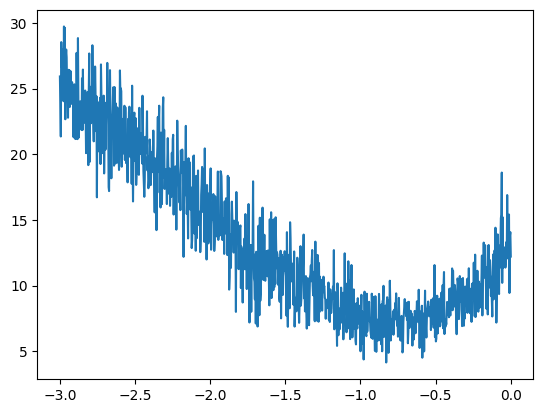

In [37]:
plt.plot(lr_exp, loss_l)

While comparing the loss in training dataset and development dataset, we can see there isn't big difference which proves our model hasn't been overfitted to data as our model have almost identical loss in unseen development dataset.

Since the purpose of `dev dataset` is to test model performance and make necessary architectural changes to improve the model performances. Therefore, we are going to make following architectural changes in the model to improve following `Karpathy`:

- We will increase the number's of neuron in our hidden `tanh` layer which was originally of 100 neurons to 200 neurons.
- We will increase the dimension of our `embeeding` layer from 2D to 10D so, that our each 27 character has 10 features to learn or correlate to each other.

Before:
```python
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2),generator=g) # we are embedding two features in each character to track some undefined special feature
W1 = torch.randn((6,100),generator=g) # we are expecting 6 inputs and pass it to 100 neurons
b1 = torch.randn(100, generator=g) # we need 100 biases in total for each neuron
W2 = torch.randn((100,27),generator=g) # we are expecting 100 output from previous layer of neuros which has 100 neurons and then pass the output as input into 27 neurons
b2 = torch.randn(27,generator=g) # we need 27 biases in total for each 27 neurons
```
After changes:
```python
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10),generator=g) # we are embedding ten features in each character to track some undefined special feature
W1 = torch.randn((30,200),generator=g) # we are expecting 30 inputs and pass it to 200 neurons
b1 = torch.randn(200, generator=g) # we need 200 biases in total for each neuron
W2 = torch.randn((200,27),generator=g) # we are expecting 200 output from previous layer of neuros which has 100 neurons and then pass the output as input into 27 neurons
b2 = torch.randn(27,generator=g) # we need 27 biases in total for each 27 neurons
```
<br/>

These changes will ultimately result in increase in the number of parameters making our model more bigger and more powerful enough to learn properly but bigger MLP might start overfitting therefore we will make following changes to prevent it from overfitting:

- We will apply weight decay to improve the model but weight decay will be applied in an unsual way or we can simply say that we will train our model different learning rates to improve it. We will train our model at the rate of `0.06` for first 100k training loop then we will intentionally reduce the learning rate to `0.01` after that.
- We will train our model in total of 200k training loop instead of initial 15k training loop
```python
for i in range(200000):
  .
  .
  .
  lr = 0.06 if i < 100000 else 0.01
  .
  .
  .
```

In [47]:
# loss calculation in training dataset
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1982, grad_fn=<NllLossBackward0>)

In [48]:
# loss calculation in dev dataset
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2333, grad_fn=<NllLossBackward0>)

#### Let's visualize our 2D embedding vector matrix of features:

We can see our final trained model which has been able to differentiate the characters based on feature. Based on first 2 features our model has learned which characters more correlate by grouping together and putting away the character which aren't similar.

_Note: I didn't plot all 10 features because 10d matrix is difficult to visualize therfore, I plotted 2D graph using 2 features among 10 of matrix `C`._

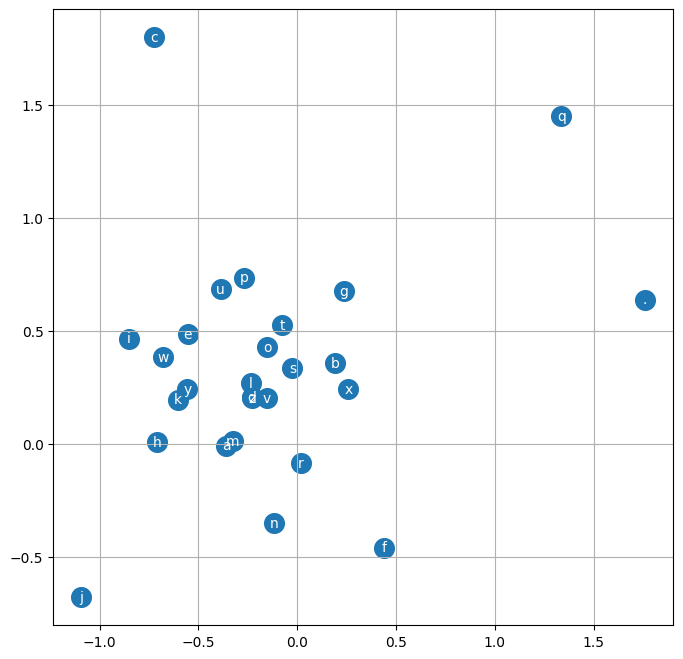

In [49]:
plt.figure(figsize= (8,8)) # draw a graph of 8 inch wide and 8 inch high
plt.scatter(C[:,0].data, C[:,1].data, s=200) # take x-axis as C[:,0].data and y-axis as C[:,1].tensor and each scatter should be of size 200
for i in range(C.shape[0]):
  plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white') # take x-axis as C[i, 0].item(), y-axis as C[i, 1].item(), write resulting string from itos[i]
plt.grid('minor') # also construct grid in the graph

#### Let's also visualize the graph of loss vs step of training loops

We can see our loss dropped very fast during our first 15k training loop but then remained consistent later which means, we can't force our model to learn more without making some architectural changes but we already have very low loss and also to avoid overfitting, we won't train anymore.

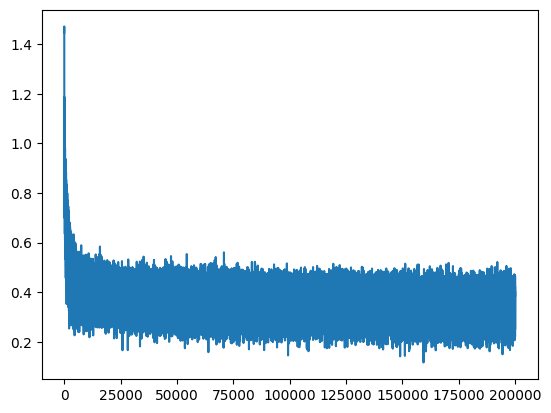

In [50]:
plt.plot(step_i, loss_l)

#### Let's look into our final evaluation of MLP using test dataset

We can see, we have achieved a loss of `2.23` in our test dataset which is way much better than our previous biagram model. And good news is that model training loss is almost near compared to training dataset. development dataset and test dataset which was never seen by MLP. This concludes that we haven't too much overfitted our MLP and it is ready for sampling.

In [51]:
# loss calculation in test dataset
emb = C[Xte]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.2382, grad_fn=<NllLossBackward0>)

#### Let's sample out some example from our model:

For sampling out of the MLP, we still use the same approach like we used in the bigram model.

This is the **generation loop**, which is where your trained model actually writes new words from scratch, character by character.

The `block_size` is 3 (meaning it looks at 3 context characters to guess the 4th).

---

### Phase 1: The Starting Line

```python
context = [0] * block_size

```

* **What it does:** Creates your initial context window. Since `block_size` is 3, `context` becomes `[0, 0, 0]`.
* **Why 0?** In Karpathy's `makemore` convention, index `0` is usually reserved for a special token (like a period `.` representing the start or end of a word). So, starting with `[0, 0, 0]` means: *"The model sees three start-tokens, now predict what comes next."*

---

### Phase 2: Why `C[torch.tensor([context])]` gives shape `torch.Size([1, 3, 10])`

Let's trace how that shape happens right at the start of the `while True:` loop:

1. `context` is `[0, 0, 0]` (length 3).
2. `torch.tensor([context])` wraps it in a batch dimension, turning it into a shape of `(1, 3)`. It represents a batch of **1 row** containing **3 characters**.
3. You pass that `(1, 3)` tensor into your embedding table `C`.
* `C` has shape `(27, 10)` (27 characters, 10 embedding dimensions each).
* PyTorch looks up index `0`, then `0`, then `0` in `C`.
* Each of those 3 integers gets replaced by a 10-dimensional vector.


4. **Resulting shape:** `(1, 3, 10)`
* `1` = Batch size (we are generating 1 word at a time).
* `3` = Context length (the 3 characters we are looking at).
* `10` = Embedding dimensions per character.



---

### Phase 3: Passing it through the neural network

```python
emb = C[torch.tensor([context])] # (1, 3, 10)
h = torch.tanh(emb.view(1, -1) @ W1 + b1) # (1, 30) @ (30, hidden_dim) -> (1, hidden_dim)
logits = h @ W2 + b2 # (1, 27)
probs = F.softmax(logits, dim=1) # (1, 27) probabilities summing to 1.0

```

* **`emb.view(1, -1)`**: Flattens the `(1, 3, 10)` tensor into a 2D matrix of shape `(1, 30)` so it can multiply with the first weight matrix `W1`.
* **`logits`**: Outputs raw scores for all 27 possible characters in your alphabet. The shape is `(1, 27)` (1 row, 27 columns of scores).
* **`probs`**: Turns those raw scores into percentages using Softmax. Now you have 27 probabilities that all add up to 1.0 (100%).

---

### Phase 4: Sampling the next character

```python
ix = torch.multinomial(probs, num_samples=1, generator=g).item()

```

* **`torch.multinomial`**: Instead of blindly picking the character with the highest score (which can make the model repetitive and robotic), `multinomial` rolls a weighted dice. If character `'a'` has a 50% probability and `'e'` has a 30% probability, `'a'` is more likely to roll, but `'e'` still has a chance.
* **`.item()`**: Extracts the chosen integer out of the tensor (e.g., it rolls index `5`, which corresponds to the letter `'d'`). `ix` is now just a plain Python integer: `5`.

---

### Phase 5: Sliding the Window (The Magic Step)

```python
context = context[1:] + [ix]
out.append(ix)

```

This is how the model "shifts its eyes" to read the next letter. Watch what happens to the list:

1. **Old context:** `[0, 0, 0]`
2. **`context[1:]`**: Drops the very first item, leaving `[0, 0]` (the last two items).
3. **`+ [ix]`**: Appends the newly generated character index (let's say `5`) to the end.
4. **New context becomes:** `[0, 0, 5]`
5. **`out.append(5)`**: Saves `5` into our output sentence tracker.

---

### Phase 6: The Loop Repeats

The `while True` loop goes back to the top:

* Now `context` is `[0, 0, 5]`.
* It passes `[0, 0, 5]` into `C`, gets shape `(1, 3, 10)`, runs it through the neural network, and rolls the dice for the *next* letter (say it rolls `18`, which is `'r'`).
* **New context becomes:** `[0, 5, 18]`
* It keeps looping and sliding the window forward: `[5, 18, 1]`, `[18, 1, 4]`, etc.

### Phase 7: Stopping condition

```python
if ix == 0:
    break

```

* If the model rolls index `0` (the stop/period token), it means the model has decided the word is finished.
* It breaks out of the `while` loop, and `print(''.join(itos[i] for i in out))` stitches all the gathered integer indices back into a readable string (like `dora.`)!

_Note: Sampled out names from our model are more natural compared to bigram model._

In [54]:
context = [0] * block_size
# we need to embed into our embedding vector C
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [55]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1) # (1, 30) @ (30, hidden_dim) -> (1, hidden_dim)
      logits = h @ W2 + b2 # (1, 27)
      probs = F.softmax(logits, dim=1) # (1, 27) probabilities summing to 1.0 softmax works similar but better than .exp() then normalizing to find probability which we did in bigram model
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix] # update the previous context by removing first character and adding new character into existing two character
      out.append(ix) # update the new character which was predicted into the list
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmahlamirilli.
kimrix.
tatlanna.
sane.
rahnen.
amerynci.
aqui.
nelmari.
chaiir.
arie.
zah.
amondin.
quintin.
lilea.
jamiquos.
eloniearynix.
kaelynn.
abben.
edi.
atetteley.
